# Bepaling van soortelijke warmte van water


# Introductie

Water heeft een enorme buffercapaciteit: je moet veel energie toevoegen om de temperatuur van water een graad te verwarmen. In dit practicum gaan we de soortelijke warmte van water bepalen door een bekende hoeveelheid water te verwarmen met een bekende hoeveelheid energie, en de temperatuurstijging te meten.

# Theorie

Soortelijke warmte: Q = c * m * delta_T --> c = Q / (m * delta_T)


# Methode en materialen

## Ontwerp
Een waterbad met bekende massa aan water wordt verwarmd met een elektrisch verwarmingselement dat een bekende hoeveelheid energie levert.
De temperatuur van het water wordt gemeten met een temperatuursensor.
Door de temperatuurstijging als functie van de tijd te meten kan de soortelijke warmte van water worden berekend.


## Materialen
Hieronder staat de lijst van benodigde materialen bij deze proef:
- Maatbeker
- Weegschaal
- Water
- Elektrisch verwarmingselement ($10 \mathrm{\Omega}$, $10 \mathrm{W}$)
- Voedingsbron 
- Thermometer of temperatuursensor
- Stopwatch of timer

```{figure} figures/cwater_setup.jpg
:width: 70%

Een schematische weergave van de opstelling
```

## Procedure
```{exercise}
1. Beschrijf de procedure die nodig is om de soortelijke warmte van water te bepalen.
2. Geef jouw beschrijving van de procedure aan een ander team, zij verzamelen voor jou de data op basis van de gegevens.
3. Voer het experiment van een ander team uit op basis van hun beschrijving.
4. Analyseer de data die het andere groepje voor jou heeft verzameld.
```

1. Doe 300 ml water in de beker
2. Sluit de verwarmingselement aan op de spanningsbron
3. Verhit het water door het voltage steeds aanpassen in stappen van 0.1 V maar blijf onder de 40 W
4. Noteer het vermogen
5. Meet steeds de begintemperatuur, zet hierbij een timer aan en wacht tot de temperatuur constant blijft. Zet dan de stopwatch stil en noteer de eindtemperatuur.
6. Meet de tijd ook



## Veiligheid
We maken gebruik van een $10 \mathrm{\Omega}$, $10 \mathrm{W}$ weerstand.
Deze wordt snel heet.
De bronspanning mag dan ook alleen aan wanneer de weerstand in het water zit.
Raak de weerstand niet aan tijdens het experiment.
Omdat de weerstand in het water zit, kunnen we wel het elektrisch vermogen hoger zetten zonder dat de weerstand oververhit raakt.
Het maximaal vermogen mag $40 \mathrm{W}$ zijn.
Daarbij moet de roerder wel aanstaan om de warmte goed te verdelen.

## Data analyse
Geef kort de data-analysemethode weer.

# Resultaten


Fitted specific heat: c = 5086.17 ± 77.88 J/(kg·°C)
Fitted initial temperature: T0 = 25.28 ± 0.18 °C


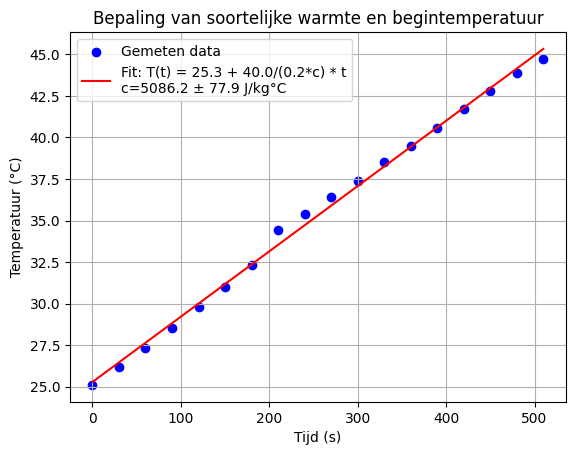

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Gegeven data
m = 0.2  # massa in kg
V = 20   # spanning in Volt
R = 10   # weerstand in Ohm

tijd = np.array([0,30,60,90,120,150,180,210,240,270,300,330,360,390,420,450,480,510])
temperatuur = np.array([25.1,26.2,27.3,28.5,29.8,31,32.3,34.4,35.4,36.4,37.4,38.5,39.5,40.6,41.7,42.8,43.9,44.7])

P = V**2 / R  # Vermogen in Watt

# Model: T(t) = T0 + (P / (m*c)) * t
def model(t, c, T0):
    return T0 + (P * t / (m * c))

# Curve fit: vind c en T0
popt, pcov = curve_fit(model, tijd, temperatuur, p0=[500, 25])
c_fit, T0_fit = popt

# Onzekerheden
sigma_c, sigma_T0 = np.sqrt(np.diag(pcov))

print(f"Fitted specific heat: c = {c_fit:.2f} ± {sigma_c:.2f} J/(kg·°C)")
print(f"Fitted initial temperature: T0 = {T0_fit:.2f} ± {sigma_T0:.2f} °C")

# Bereken fitted waarden voor plot
t_fit = np.linspace(0, 510, 500)
T_fit = model(t_fit, *popt)

# Plotten
plt.scatter(tijd, temperatuur, label="Gemeten data", color="blue")
plt.plot(t_fit, T_fit, label=f"Fit: T(t) = {T0_fit:.1f} + {P:.1f}/({m}*c) * t\nc={c_fit:.1f} ± {sigma_c:.1f} J/kg°C", color="red")
plt.xlabel("Tijd (s)")
plt.ylabel("Temperatuur (°C)")
plt.title("Bepaling van soortelijke warmte en begintemperatuur")
plt.legend()
plt.grid(True)
plt.show()


In [4]:
plt.savefig("figures/naam.png", dpi=450)



<Figure size 640x480 with 0 Axes>

# Discussie en conclusie

Hier een korte discussie en conclusie over de resultaten van het experiment en de implicaties daarvan.

Uit ons onderzocht is een experiment waarde van de soortelijke warmte gevonden van 5086.17 +- 77.9 J/(kg·°C), terwijl volgens de literatuur de soortelijke warmte van water 4180 J/(kg·°C) is. Dit is een verschil van 21.7%. Dit kan komen door warmteverlies naar de omgeving, waardoor het water snel zou afkoelen, wat leidt tot een hogere waarde voor c en door de soortelijke warmte van het glas te verwaarlosen. De onzekerheid is klein, wat aangeeft dat de meetfouten klein zijn. Uit deze methode kan een ruwe schatting van de soortelijke warmte van water gehaald worden. Om een experimentele waarde te vinden die dichter bij de literatuurwaarde ligt, zal het warmteverlies gemeten moeten worden of geminimaliseerd word en moet de soortelijke warmte van het glas bekend zijn en meegenomen worden in de berekening. 

